In [21]:
%%capture
%pip install pymorphy3
%pip install wordcloud
%pip install catboost
%pip install google.colab
%pip install fasttext
%pip install transformers datasets accelerate
%pip install evaluate

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
import warnings
import joblib
import ast
import fasttext
import fasttext.util
import torch
import os
import evaluate

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from pymorphy3 import MorphAnalyzer
from wordcloud import WordCloud

from collections import Counter

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset

warnings.filterwarnings("ignore")

# Предобработка текстов

In [ ]:
df = pd.read_csv('data/dataset.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41161 entries, 0 to 41160
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        41161 non-null  int64  
 1   url       41161 non-null  object 
 2   title     41161 non-null  object 
 3   subtitle  40946 non-null  object 
 4   content   41158 non-null  object 
 5   datetime  41161 non-null  object 
 6   topic     41161 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 2.2+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

> дубликатов нет!

Почистим датасет от пустых или слишком коротких текстов

In [ ]:
df = df.dropna(subset=['content'])

In [ ]:
short_texts = df['content'].apply(lambda x: len(str(x).strip()) < 80).sum()
short_texts

np.int64(0)

> совсем коротких текстов нет

Почистим от мусора и нормализуем текст

In [ ]:
def clean_text(text):

    text = str(text).lower() # нижний регистр

    text = re.sub(r'<[^>]+>', '', text) # чистим от html-тегов
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # чистим от url
    text = re.sub(r'[^а-яё\s]', '', text) # убираем знаки и цифры
    text = re.sub(r'\s+', ' ', text).strip() # убираем лишние пробелы

    return text

In [ ]:
def preprocess_text(text, morph, stop_words):
    """
    Полная предобработка текста: очистка -> токенизация -> лемматизация -> фильтрация
    """

    text = clean_text(text)

    tokens = word_tokenize(text)
    tokens = [morph.parse(token)[0].normal_form for token in tokens]
    tokens = [token for token in tokens if token not in stop_words and len(token) > 1]

    return tokens

In [ ]:
df['content'] = df['content'].apply(clean_text)

Токенизируем + лемматизируем

In [ ]:
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
stop_words = set(stopwords.words('russian'))

In [ ]:
morph = MorphAnalyzer()

In [ ]:
df['tokens'] = df['content'].apply(word_tokenize)
df['tokens'] = df['tokens'].apply(
    lambda x: [morph.parse(token)[0].normal_form for token in x])

In [ ]:
df.head()

,id,url,title,subtitle,content,datetime,topic,tokens
0,2062742045,https://ria.ru/20251217/pdvsa-2062742045.html,PDVSA заявила о штатном режиме экспорта нефти,PDVSA заявила о штатном режиме экспорта нефти ...,экспорт нефти и нефтепродуктов венесуэлы осуще...,18:20 17.12.2025,1.0,"[экспорт, нефть, и, нефтепродукт, венесуэла, о..."
1,2062740630,https://ria.ru/20251217/aziya-2062740630.html,Эксперт рассказал о новом этапе в сотрудничест...,Манчевич: сотрудничество России и Азии перешло...,локализация высокотехнологичного производства ...,18:15 17.12.2025,1.0,"[локализация, высокотехнологичный, производств..."
2,2062738407,https://ria.ru/20251217/ssha-2062738407.html,США разрешили транспортировку нефти с проекта ...,"США разрешили финоперации, связанные с проекто...",минфин сша в среду разрешил финансовые операци...,18:09 17.12.2025,1.0,"[минфин, сша, в, среда, разрешить, финансовый,..."
3,2062732693,https://ria.ru/20251217/roseksimbank-206273269...,"Кредитный продукт ""Деньги на экспорт"" от Росэк...","Кредитный продукт ""Деньги на экспорт"" от Росэк...",кредитный продукт деньги на экспорт от росэкси...,17:55 17.12.2025,1.0,"[кредитный, продукт, деньга, на, экспорт, от, ..."
4,2062732296,https://ria.ru/20251217/eksar-2062732296.html,"Агентство ""Эксар"" подвело итоги работы с банка...","Агентство ""Эксар"" провело итоговое в 2025 г за...",российское агентство по страхованию экспортных...,17:54 17.12.2025,1.0,"[российский, агентство, по, страхование, экспо..."


In [ ]:
df['tokens'].sample(6)

17189    [фото, алевтина, запольский, часть, сотрудник,...
35912    [фото, павел, лисицын, риа, новость, константи...
33935    [фото, платон, щукин, индекс, менеджер, по, за...
27486    [фото, сергей, фадеичев, тасс, анастасия, бори...
34717    [фото, юрий, леонов, вооружённый, сила, украин...
3952     [фото, риа, новость, татьяна, романов, на, пло...
Name: tokens, dtype: object

In [ ]:
df['tokens'] = df['tokens'].apply(
    lambda x: [token for token in x if token not in stop_words and len(token) > 1])

Попробуем найти мусорные токены среди самых частых

In [ ]:
all_tokens = [token for sublist in df['tokens'] for token in sublist]
token_counts = Counter(all_tokens)

pd.DataFrame(token_counts.most_common(20))

,0,1
0,год,136768
1,это,117931
2,который,86325
3,россия,71216
4,фото,68068
5,страна,48196
6,свой,45570
7,стать,41685
8,российский,41363
9,процент,41246


> Мусорными кажутся все

In [ ]:
joblib.dump(stop_words, 'data/stop_words_updated.joblib')

['data/stop_words_updated.joblib']

In [ ]:
most_common_tokens = [token for token, count in token_counts.most_common(20)]
stop_words.update(most_common_tokens)
joblib.dump(stop_words, 'data/stop_words.joblib')

df['tokens'] = df['tokens'].apply(
    lambda x: [token for token in x if token not in stop_words])

In [ ]:
all_tokens = [token for sublist in df['tokens'] for token in sublist]
token_counts = Counter(all_tokens)

pd.DataFrame(token_counts.most_common(20))

,0,1
0,президент,24075
1,проект,23153
2,развитие,23046
3,работа,22768
4,ранее,22698
5,заявить,22577
6,компания,22308
7,рубль,22192
8,день,21740
9,новость,21065


Найдем для каждого значения topic топ-10 популярных токенов и почистим пересечения (считаем, что если токен встречается часто в каждой теме - тогда он мусорный)

In [ ]:
top_tokens_by_topic = {}

for topic in df['topic'].unique():
    topic_tokens = []
    for tokens in df[df['topic'] == topic]['tokens']:
        topic_tokens.extend(tokens)

    token_counts = Counter(topic_tokens)
    top_tokens = [token for token, count in token_counts.most_common(10)]
    top_tokens_by_topic[topic] = top_tokens

In [ ]:
top_tokens_by_topic

{np.float64(1.0): ['компания',
  'рубль',
  'рост',
  'рынок',
  'развитие',
  'проект',
  'ранее',
  'тысяча',
  'доллар',
  'цена'],
 np.float64(0.0): ['день',
  'президент',
  'область',
  'проект',
  'наш',
  'регион',
  'развитие',
  'работа',
  'отметить',
  'ребёнок'],
 np.float64(8.0): ['советский',
  'война',
  'учёный',
  'ссср',
  'работа',
  'ещё',
  'новость',
  'риа',
  'жизнь',
  'русский'],
 np.float64(2.0): ['дело',
  'суд',
  'рубль',
  'задержать',
  'сотрудник',
  'уголовный',
  'миллион',
  'область',
  'данные',
  'ранее'],
 np.float64(3.0): ['украина',
  'украинский',
  'всу',
  'президент',
  'заявить',
  'ранее',
  'сила',
  'военный',
  'вооружённый',
  'республика'],
 np.float64(4.0): ['спорт',
  'спортсмен',
  'олимпийский',
  'игра',
  'заявить',
  'международный',
  'турнир',
  'команда',
  'сборная',
  'россиянин'],
 np.float64(6.0): ['строительство',
  'проект',
  'сша',
  'развитие',
  'город',
  'работа',
  'дом',
  'ещё',
  'тысяча',
  'президент'],
 

In [ ]:
token_sets = [set(tokens) for tokens in top_tokens_by_topic.values()]

# Находим пересечение всех множеств
common_tokens = set.intersection(*token_sets)

print("Общие токены для всех topics:")
print(common_tokens)

Общие токены для всех topics:
set()


> таких токенов нет  :(

In [ ]:
df.to_csv('data/preprocessed_dataset_2.csv', index=False)

Выведем вордклауды для каждой темы

In [ ]:
token_freq_by_topic = {}

for topic in df['topic'].unique():
    topic_tokens = []
    for tokens in df[df['topic'] == topic]['tokens']:
        topic_tokens.extend(tokens)

    token_counts = Counter(topic_tokens)
    token_freq_by_topic[topic] = dict(token_counts.most_common(100))

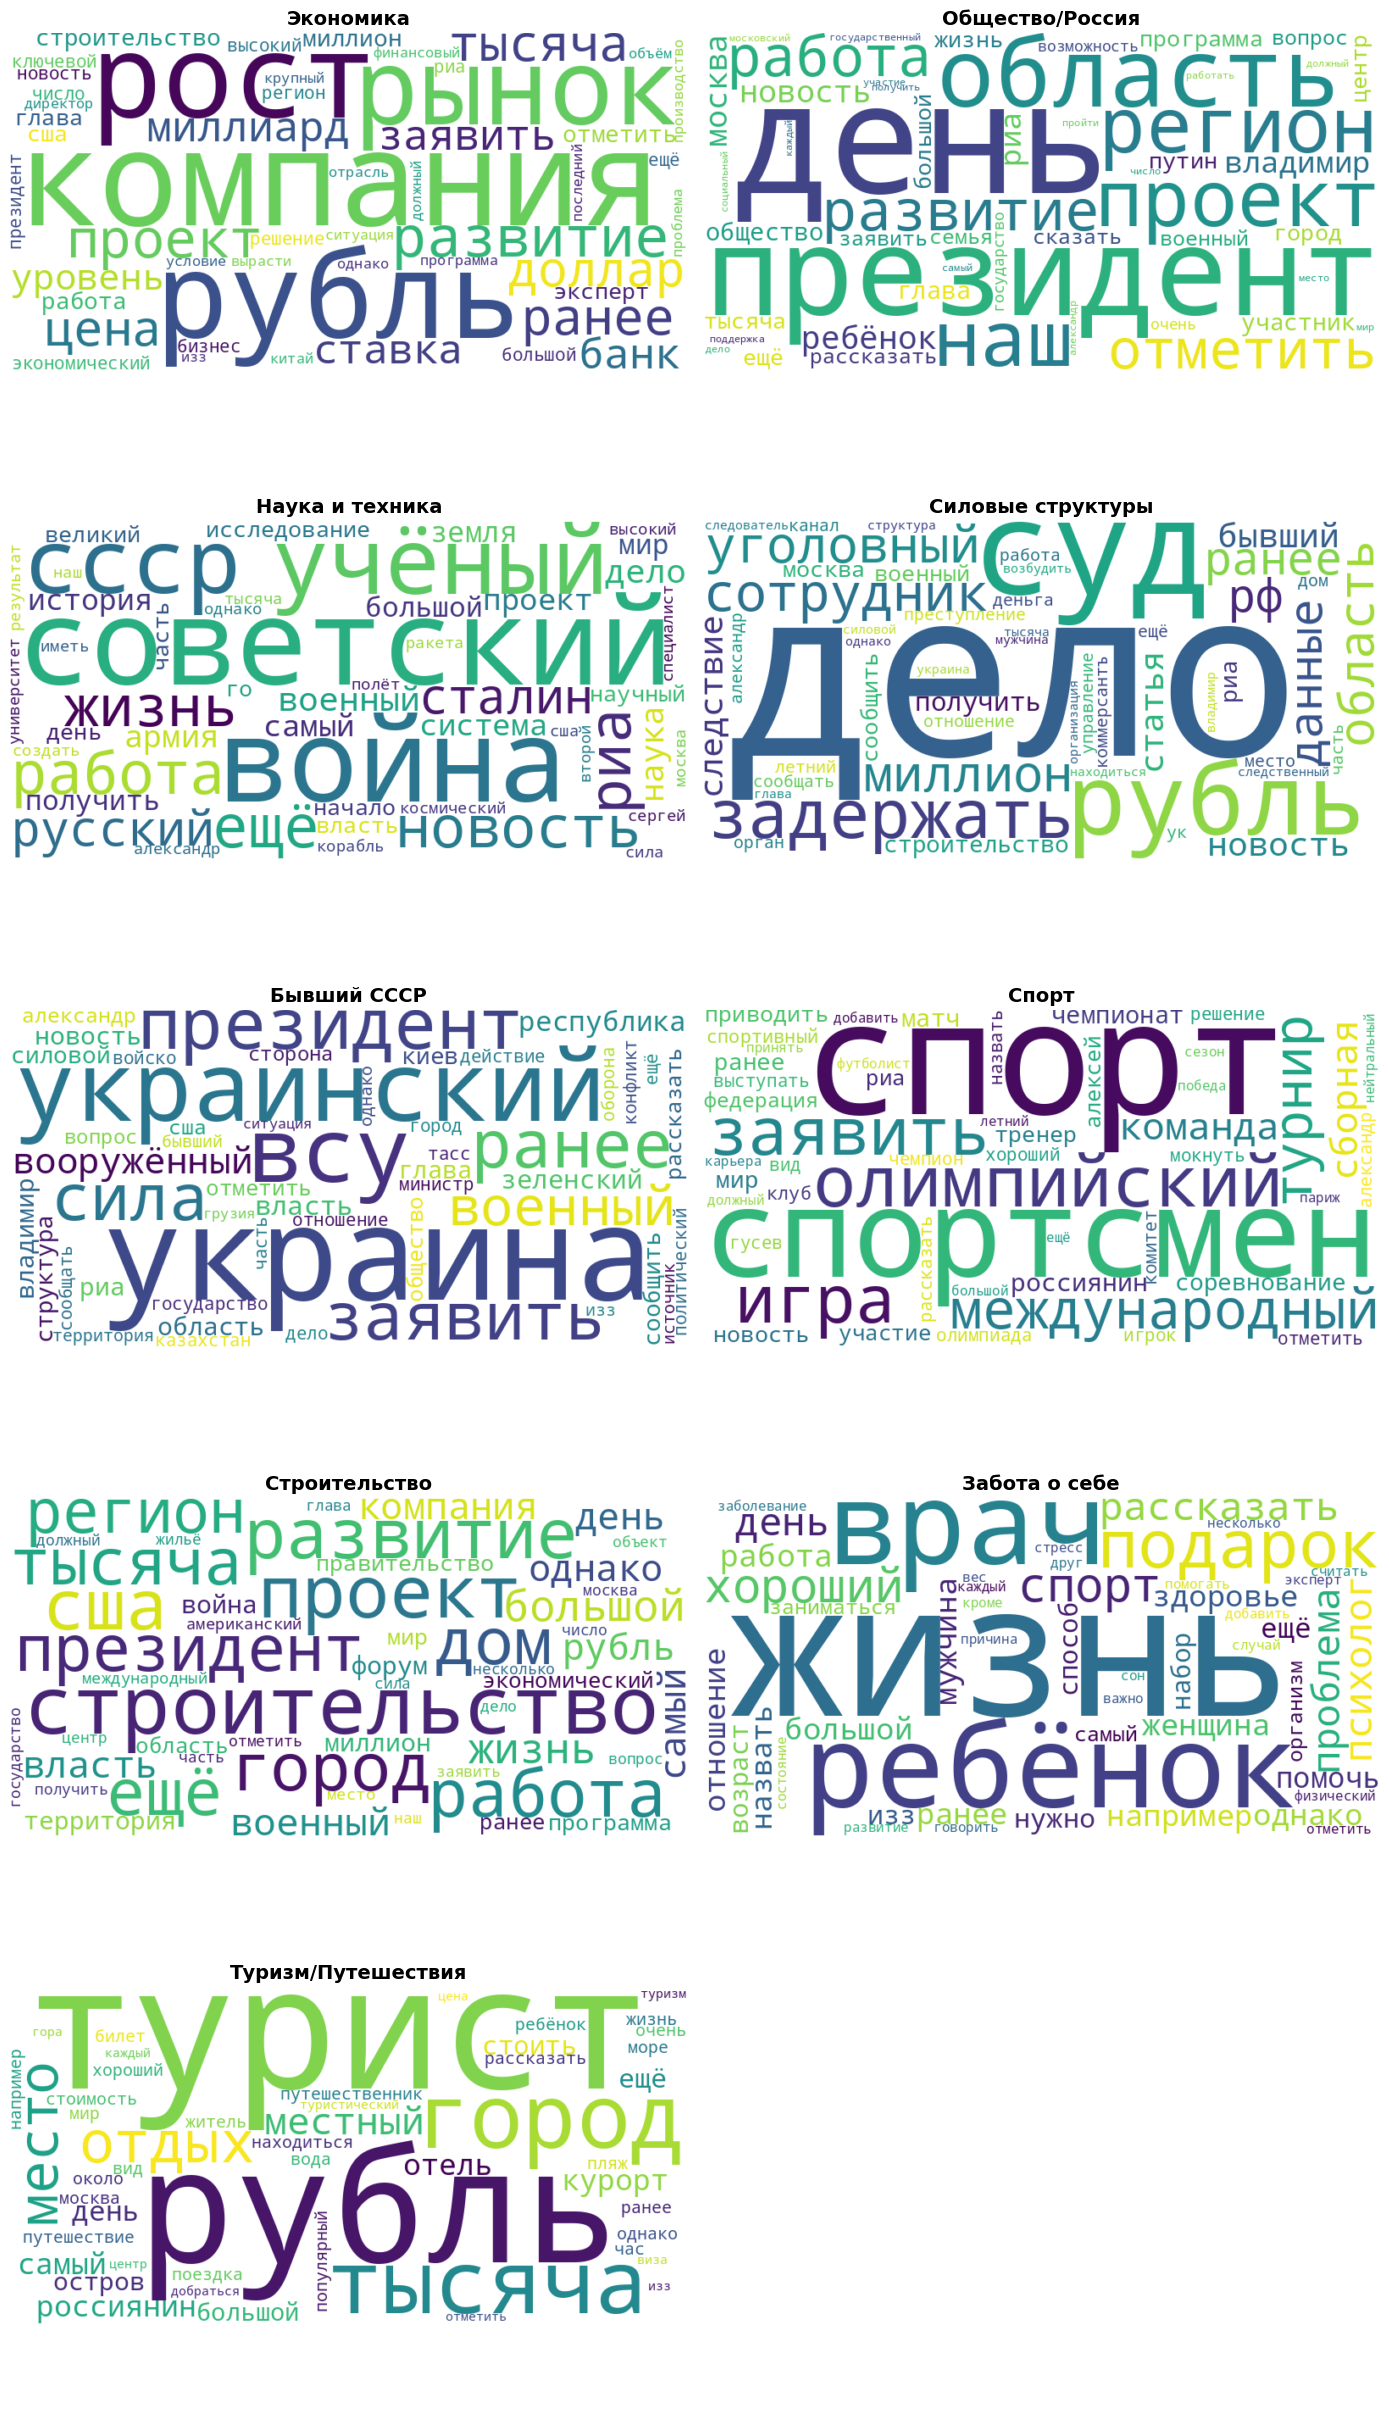

In [ ]:
n_topics = 9
cols = 2
rows = (n_topics + 1) // 2

topic_names = {
    0: 'Общество/Россия',
    1: 'Экономика',
    2: 'Силовые структуры',
    3: 'Бывший СССР',
    4: 'Спорт',
    5: 'Забота о себе',
    6: 'Строительство',
    7: 'Туризм/Путешествия',
    8: 'Наука и техника'
}

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()

for idx, topic in enumerate(token_freq_by_topic.keys()):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        max_words=50
    ).generate_from_frequencies(token_freq_by_topic[topic])

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'{topic_names.get(topic, topic)}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

# Скрываем лишние сабплоты
for idx in range(n_topics, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Векторизация + обучение моделей

In [3]:
df = pd.read_csv('data/preprocessed_dataset.csv')
df['tokens'] = df['tokens'].apply(ast.literal_eval)
df['clean_text'] = df['tokens'].apply(' '.join)

In [4]:
df.head()

,id,url,title,subtitle,content,datetime,topic,tokens,clean_text
0,2062742045,https://ria.ru/20251217/pdvsa-2062742045.html,PDVSA заявила о штатном режиме экспорта нефти,PDVSA заявила о штатном режиме экспорта нефти ...,экспорт нефти и нефтепродуктов венесуэлы осуще...,18:20 17.12.2025,1.0,"[экспорт, нефть, нефтепродукт, венесуэла, осущ...",экспорт нефть нефтепродукт венесуэла осуществл...
1,2062740630,https://ria.ru/20251217/aziya-2062740630.html,Эксперт рассказал о новом этапе в сотрудничест...,Манчевич: сотрудничество России и Азии перешло...,локализация высокотехнологичного производства ...,18:15 17.12.2025,1.0,"[локализация, высокотехнологичный, производств...",локализация высокотехнологичный производство т...
2,2062738407,https://ria.ru/20251217/ssha-2062738407.html,США разрешили транспортировку нефти с проекта ...,"США разрешили финоперации, связанные с проекто...",минфин сша в среду разрешил финансовые операци...,18:09 17.12.2025,1.0,"[минфин, сша, среда, разрешить, финансовый, оп...",минфин сша среда разрешить финансовый операция...
3,2062732693,https://ria.ru/20251217/roseksimbank-206273269...,"Кредитный продукт ""Деньги на экспорт"" от Росэк...","Кредитный продукт ""Деньги на экспорт"" от Росэк...",кредитный продукт деньги на экспорт от росэкси...,17:55 17.12.2025,1.0,"[кредитный, продукт, деньга, экспорт, росэксим...",кредитный продукт деньга экспорт росэксимбанк ...
4,2062732296,https://ria.ru/20251217/eksar-2062732296.html,"Агентство ""Эксар"" подвело итоги работы с банка...","Агентство ""Эксар"" провело итоговое в 2025 г за...",российское агентство по страхованию экспортных...,17:54 17.12.2025,1.0,"[российский, агентство, страхование, экспортны...",российский агентство страхование экспортный кр...


In [5]:
X = df['clean_text']
y = df['topic']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=42,
                                                    stratify=y)

In [6]:
X_train.shape, X_test.shape

((30868,), (10290,))

Мне известны 2 метода векторизации - Bag of Words и TF-IDF, поэтому использовать будем их

- BoW - просто подсчитывает частоту слов в документе, создавая вектор, где каждое слово имеет одинаковый вес

- TF-IDF учитывает частоту слов, но дополнительно штрафует веса токенов, которые встречаются во многих текстах (чем чаще слово встречается в одном документе и реже в других, тем выше его вес)

## BoW + LogReg

Пайплайн №1: Bag of Words + LogReg

In [ ]:
bow_logreg = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

bow_logreg.fit(X_train, y_train)

y_pred_bow = bow_logreg.predict(X_test)
acc_bow = accuracy_score(y_test, y_pred_bow)
print(f"Test Accuracy: {acc_bow:.4f}")

In [ ]:
bow_logreg = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_bow = {
    'vectorizer__max_features': [10000],
    'vectorizer__ngram_range': [(1, 2)],
    'vectorizer__min_df': [2],
    'vectorizer__max_df': [0.95],

    'clf__C': [0.01, 0.05, 0.1],
}

grid_bow = GridSearchCV(
    bow_logreg,
    param_grid_bow,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_bow.fit(X_train, y_train)

print(f"Accuracy: {grid_bow.best_score_:.4f}")

In [ ]:
grid_bow.best_params_

{'clf__C': 0.1,
 'vectorizer__max_df': 0.95,
 'vectorizer__max_features': 10000,
 'vectorizer__min_df': 2,
 'vectorizer__ngram_range': (1, 2)}

In [ ]:
y_pred_bow = grid_bow.predict(X_test)
acc_bow = accuracy_score(y_test, y_pred_bow)
print(f"Test Accuracy: {acc_bow:.4f}")

Test Accuracy: 0.8833


## TF-IDF + LogReg

Пайплайн №2: TF-IDF + LogReg

In [ ]:
tfidf_logreg = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_tfidf = {
    # Vectorizer параметры
    'vectorizer__max_features': [10000, 20000],
    'vectorizer__ngram_range': [(1, 2), (1, 3)],
    'vectorizer__min_df': [2, 3],
    'vectorizer__max_df': [0.90, 0.95],

    # LogisticRegression параметры
    'clf__C': [5, 7]
}

grid_tfidf = GridSearchCV(
    tfidf_logreg,
    param_grid_tfidf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=3
)

grid_tfidf.fit(X_train, y_train)

print(f"Accuracy: {grid_tfidf.best_score_:.4f}")

In [ ]:
joblib.dump(grid_tfidf.best_params_, 'tfidf_params.joblib')
grid_tfidf.best_params_

{'clf__C': 7,
 'vectorizer__max_df': 0.9,
 'vectorizer__max_features': 20000,
 'vectorizer__min_df': 2,
 'vectorizer__ngram_range': (1, 2)}

In [ ]:
y_pred_tfidf = grid_tfidf.predict(X_test)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
print(f"Test Accuracy: {acc_tfidf:.4f}")

Test Accuracy: 0.8997


## TF-IDF + LinearSVC

Пайплайн №3: TF-IDF + линейный SVC

In [ ]:
tfidf_svc = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('clf', LinearSVC(random_state=42, max_iter=2000))
])

param_grid_svc = {
    'vectorizer__max_features': [10000],
    'vectorizer__ngram_range': [(1, 2)],
    'vectorizer__min_df': [2],
    'vectorizer__max_df': [0.95],
    'vectorizer__sublinear_tf': [True],

    'clf__C': [0.5, 1.0, 2.0],
}

grid_svc = GridSearchCV(
    tfidf_svc,
    param_grid_svc,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_svc.fit(X_train, y_train)

print(f"Accuracy: {grid_svc.best_score_:.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Accuracy: 0.8924


In [ ]:
joblib.dump(grid_svc.best_params_, 'tfidf_svc_params.joblib')
grid_svc.best_params_

{'clf__C': 0.5,
 'vectorizer__max_df': 0.95,
 'vectorizer__max_features': 10000,
 'vectorizer__min_df': 2,
 'vectorizer__ngram_range': (1, 2),
 'vectorizer__sublinear_tf': True}

In [ ]:
tfidf_svc = Pipeline([
    ('vectorizer', TfidfVectorizer(max_df=0.95,
                                   max_features=10000,
                                   min_df=2,
                                   ngram_range=(1,2),
                                   sublinear_tf=True)),
    ('clf', LinearSVC(C=0.5, random_state=42, max_iter=2000))
])

tfidf_svc.fit(X_train, y_train)

y_pred_svc = tfidf_svc.predict(X_test)
acc_svc = accuracy_score(y_test, y_pred_svc)
print(f"Test Accuracy: {acc_svc:.4f}")

Test Accuracy: 0.8991


## TF-IDF + VotingClassifier

In [ ]:
best_params = joblib.load('tfidf_params.joblib')

vectorizer = TfidfVectorizer(
    max_features=best_params['vectorizer__max_features'],
    ngram_range=best_params['vectorizer__ngram_range'],
    min_df=best_params['vectorizer__min_df'],
    max_df=best_params['vectorizer__max_df']
)


X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

classifiers = {
    'LogisticRegression': LogisticRegression(
        C=1, max_iter=1000, random_state=42, n_jobs=-1
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100, max_depth=20, random_state=42, n_jobs=-1
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=100, max_depth=20, random_state=42, n_jobs=-1
    ),
    'SVM': LinearSVC(C=1, random_state=42, max_iter=2000),  # LinearSVC быстрее SVC
    'CatBoost': CatBoostClassifier(
        iterations=100, depth=6, learning_rate=0.1,
        verbose=0, random_state=42, thread_count=-1
    ),
}

metrics = []
trained_models = {}

for name, clf in classifiers.items():
    print(f"Training {name}...")

    clf.fit(X_train_tfidf, y_train)
    y_pred = clf.predict(X_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)

    trained_models[name] = clf
    metrics.append({'Model': name, 'Accuracy': accuracy})
    print(f"{name}: {accuracy:.4f}")

print(pd.DataFrame(metrics))

Training LogisticRegression...
LogisticRegression: 0.8826
Training RandomForest...
RandomForest: 0.7456
Training ExtraTrees...
ExtraTrees: 0.6644
Training SVM...
SVM: 0.9026
Training CatBoost...


In [ ]:
voting_clf = VotingClassifier(
    estimators=[(name, model) for name, model in search_results.items()],
    voting='soft'
)
voting_clf.fit(X_train, y_train)

y_pred_voting = voting_clf.predict(X_test)
accuracy_voting = accuracy_score(y_test, y_pred_voting)

metrics.append({'Model': 'VotingClassifier', 'Accuracy': accuracy_voting})
metrics_df = pd.DataFrame(metrics)

## FastText (pre-trained) + LogReg

In [ ]:
X = df['tokens']
y = df['topic']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=42,
                                                    stratify=y)

In [ ]:
if not os.path.exists('models/cc.ru.300.bin'):
    fasttext.util.download_model('ru', if_exists='ignore')

ft_model = fasttext.load_model('models/cc.ru.300.bin')

In [ ]:
def get_document_embedding(tokens, model):
    """
    Получает эмбеддинг документа как среднее векторов слов
    """
    if not tokens or len(tokens) == 0:
        return np.zeros(model.get_dimension())

    vectors = [model.get_word_vector(token) for token in tokens]
    return np.mean(vectors, axis=0)

In [ ]:
X_train_ft = np.array([get_document_embedding(tokens, ft_model) for tokens in X_train])
X_test_ft = np.array([get_document_embedding(tokens, ft_model) for tokens in X_test])

In [ ]:
X_train_ft.shape, X_test_ft.shape

((30868, 300), (10290, 300))

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_ft)
X_test_scaled = scaler.transform(X_test_ft)

In [ ]:
logreg_ft = LogisticRegression(max_iter=1000, random_state=42)
logreg_ft.fit(X_train_scaled, y_train)

y_pred_ft = logreg_ft.predict(X_test_scaled)
acc_ft = accuracy_score(y_test, y_pred_ft)
print(f"Test Accuracy (FastText pretrained + LogReg): {acc_ft:.4f}")

Test Accuracy (FastText pretrained + LogReg): 0.8116


## FastText + LogReg

In [ ]:
X = df['tokens']
y = df['topic']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=42,
                                                    stratify=y)

In [ ]:
train_texts = df['clean_text'].tolist()

with open('data/fasttext_train.txt', 'w', encoding='utf-8') as f:
    for text in train_texts:
        f.write(text + '\n')


ft_custom = fasttext.train_unsupervised(
    'data/fasttext_train.txt',
    model='skipgram',
    dim=100,
    ws=5,
    minCount=2,
    epoch=10,
    lr=0.05
)

Read 10M words
Number of words:  90396
Number of labels: 0
Progress: 100.0% words/sec/thread:   44035 lr:  0.000000 avg.loss:  1.321016 ETA:   0h 0m 0s


In [ ]:
ft_custom.save_model('models/fasttext_custom.bin')

In [ ]:
X_train_custom = np.array([get_document_embedding(tokens, ft_custom) for tokens in X_train])
X_test_custom = np.array([get_document_embedding(tokens, ft_custom) for tokens in X_test])

In [ ]:
scaler_custom = StandardScaler()

X_train_custom_scaled = scaler_custom.fit_transform(X_train_custom)
X_test_custom_scaled = scaler_custom.transform(X_test_custom)

In [ ]:
logreg_custom = LogisticRegression(max_iter=1000, random_state=42)
logreg_custom.fit(X_train_custom_scaled, y_train)

y_pred_custom = logreg_custom.predict(X_test_custom_scaled)
acc_custom = accuracy_score(y_test, y_pred_custom)
print(f"Test Accuracy (FastText custom + LogReg): {acc_custom:.4f}")

Test Accuracy (FastText custom + LogReg): 0.8262


## BERT + LogReg

In [ ]:
model_name = "DeepPavlov/rubert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

bert_model.eval()

In [ ]:
def get_bert_embeddings_batch(texts, tokenizer, model, device, batch_size=32, max_length=512):
    """
    Получает эмбеддинги для списка текстов батчами.
    Батчевая обработка значительно ускоряет процесс.
    """
    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]

        # Токенизация батча
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        )

        input_ids = encoded['input_ids'].to(device)
        attention_mask = encoded['attention_mask'].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # [CLS] токены для всего батча
        batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(batch_embeddings)

        # Прогресс
        if (i // batch_size) % 10 == 0:
            print(f"Обработано {min(i + batch_size, len(texts))}/{len(texts)} текстов")

    return np.vstack(embeddings)

In [ ]:
df = pd.read_csv('data/preprocessed_dataset.csv')

X = df['content'].fillna('').tolist()
y = df['topic']

X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
X_train_bert = get_bert_embeddings_batch(
    X_train_texts, tokenizer, bert_model, device, batch_size=16
)

X_test_bert = get_bert_embeddings_batch(
    X_test_texts, tokenizer, bert_model, device, batch_size=16
)

Обработано 16/30868 текстов
Обработано 176/30868 текстов
Обработано 336/30868 текстов
Обработано 496/30868 текстов
Обработано 656/30868 текстов
Обработано 816/30868 текстов
Обработано 976/30868 текстов
Обработано 1136/30868 текстов
Обработано 1296/30868 текстов
Обработано 1456/30868 текстов
Обработано 1616/30868 текстов
Обработано 1776/30868 текстов
Обработано 1936/30868 текстов
Обработано 2096/30868 текстов
Обработано 2256/30868 текстов
Обработано 2416/30868 текстов
Обработано 2576/30868 текстов
Обработано 2736/30868 текстов
Обработано 2896/30868 текстов
Обработано 3056/30868 текстов
Обработано 3216/30868 текстов
Обработано 3376/30868 текстов
Обработано 3536/30868 текстов
Обработано 3696/30868 текстов
Обработано 3856/30868 текстов
Обработано 4016/30868 текстов
Обработано 4176/30868 текстов
Обработано 4336/30868 текстов
Обработано 4496/30868 текстов
Обработано 4656/30868 текстов
Обработано 4816/30868 текстов
Обработано 4976/30868 текстов
Обработано 5136/30868 текстов
Обработано 5296/30

In [ ]:
np.save('data/X_train_bert.npy', X_train_bert)
np.save('data/X_test_bert.npy', X_test_bert)

In [ ]:
scaler_bert = StandardScaler()

X_train_bert_scaled = scaler_bert.fit_transform(X_train_bert)
X_test_bert_scaled = scaler_bert.transform(X_test_bert)

In [ ]:
logreg_bert = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
logreg_bert.fit(X_train_bert_scaled, y_train)

y_pred_bert = logreg_bert.predict(X_test_bert_scaled)
acc_bert = accuracy_score(y_test, y_pred_bert)
print(f"Test Accuracy (BERT + LogReg): {acc_bert:.4f}")

Test Accuracy (BERT + LogReg): 0.8249


In [ ]:
os.environ["TOKENIZERS_PARALLELISM"] = "false"

param_grid_bert = {
    'C': [0.1, 0.5, 1.0, 2.0, 5.0],
    'solver': ['lbfgs', 'saga'],
    'class_weight': [None, 'balanced']
}

grid_bert = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_bert,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_bert.fit(X_train_bert_scaled, y_train)
print(f"Best CV Accuracy: {grid_bert.best_score_:.4f}")
print(f"Best params: {grid_bert.best_params_}")

# %%
y_pred_bert_tuned = grid_bert.predict(X_test_bert_scaled)
acc_bert_tuned = accuracy_score(y_test, y_pred_bert_tuned)
print(f"Test Accuracy (BERT + LogReg tuned): {acc_bert_tuned:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


KeyboardInterrupt: 

## Fine-tuned BERT

In [11]:
df = pd.read_csv('data/dataset.csv')
df['text'] = df['content'].fillna('')
df.head()

,id,url,title,subtitle,content,datetime,topic,text
0,2062742045,https://ria.ru/20251217/pdvsa-2062742045.html,PDVSA заявила о штатном режиме экспорта нефти,PDVSA заявила о штатном режиме экспорта нефти ...,Экспорт нефти и нефтепродуктов Венесуэлы осуще...,18:20 17.12.2025,1.0,Экспорт нефти и нефтепродуктов Венесуэлы осуще...
1,2062740630,https://ria.ru/20251217/aziya-2062740630.html,Эксперт рассказал о новом этапе в сотрудничест...,Манчевич: сотрудничество России и Азии перешло...,Локализация высокотехнологичного производства ...,18:15 17.12.2025,1.0,Локализация высокотехнологичного производства ...
2,2062738407,https://ria.ru/20251217/ssha-2062738407.html,США разрешили транспортировку нефти с проекта ...,"США разрешили финоперации, связанные с проекто...",Минфин США в среду разрешил финансовые операци...,18:09 17.12.2025,1.0,Минфин США в среду разрешил финансовые операци...
3,2062732693,https://ria.ru/20251217/roseksimbank-206273269...,"Кредитный продукт ""Деньги на экспорт"" от Росэк...","Кредитный продукт ""Деньги на экспорт"" от Росэк...","Кредитный продукт ""Деньги на экспорт"" от Росэк...",17:55 17.12.2025,1.0,"Кредитный продукт ""Деньги на экспорт"" от Росэк..."
4,2062732296,https://ria.ru/20251217/eksar-2062732296.html,"Агентство ""Эксар"" подвело итоги работы с банка...","Агентство ""Эксар"" провело итоговое в 2025 г за...",Российское агентство по страхованию экспортных...,17:54 17.12.2025,1.0,Российское агентство по страхованию экспортных...


In [12]:
X = df['text']
y = df['topic']

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 28812, Val: 6174, Test: 6175


In [15]:
device = torch.device('cpu')

model_name = "DeepPavlov/rubert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=9,
    problem_type="single_label_classification"
)

model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

In [16]:
train_dataset = Dataset.from_dict({
    'text': X_train.tolist(),
    'label': y_train.tolist()
})

val_dataset = Dataset.from_dict({
    'text': X_val.tolist(),
    'label': y_val.tolist()
})

test_dataset = Dataset.from_dict({
    'text': X_test.tolist(),
    'label': y_test.tolist()
})

print(f"Train dataset: {train_dataset}")
print(f"Val dataset: {val_dataset}")

Train dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 28812
})
Val dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 6174
})


In [17]:
def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=256  # можно увеличить до 512 если хватает памяти
    )

In [18]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text'],
    desc="Tokenizing train"
)

val_dataset = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text'],
    desc="Tokenizing val"
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=['text'],
    desc="Tokenizing test"
)

Tokenizing test: 100%|██████████| 6175/6175 [00:01<00:00, 5738.94 examples/s]


In [20]:
train_dataset.set_format('torch')
val_dataset.set_format('torch')
test_dataset.set_format('torch')

In [23]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

In [26]:
training_args = TrainingArguments(
    output_dir='./rubert_finetuned',
    
    # Эпохи и батчи
    num_train_epochs=4,
    per_device_train_batch_size=16,  # уменьшить до 8 если не хватает памяти
    per_device_eval_batch_size=32,
    
    # Learning rate и scheduler
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    
    # Оценка и сохранение
    eval_strategy='steps',
    eval_steps=200,
    save_strategy='steps',
    save_steps=200,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    greater_is_better=True,
    
    # Оптимизации
    fp16=torch.cuda.is_available(),
    gradient_accumulation_steps=2,
    dataloader_num_workers=2,
    
    # Логирование
    logging_dir='./logs',
    logging_steps=100,
    report_to='none',  # отключаем wandb и т.д.
    
    # Seed
    seed=42,
)

In [27]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

In [28]:
print("Начинаем обучение...")
train_result = trainer.train()

# %%
# Выводим результаты обучения
print(f"\nРезультаты обучения:")
print(f"Training loss: {train_result.training_loss:.4f}")
print(f"Training time: {train_result.metrics['train_runtime']:.1f} sec")

# %%
# Оцениваем на валидации
val_results = trainer.evaluate()
print(f"\nValidation Accuracy: {val_results['eval_accuracy']:.4f}")

# %%
# Оцениваем на тесте
test_results = trainer.evaluate(test_dataset)
print(f"\nTest Accuracy: {test_results['eval_accuracy']:.4f}")

Начинаем обучение...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Step,Training Loss,Validation Loss


KeyboardInterrupt: 

# Финальная модель

In [ ]:
best_params = joblib.load('tfidf_params.joblib')
print(f"Лучшие параметры: {best_params}")

final_model = Pipeline([
    ('vectorizer', TfidfVectorizer(
        max_features=best_params['vectorizer__max_features'],
        ngram_range=best_params['vectorizer__ngram_range'],
        min_df=best_params['vectorizer__min_df'],
        max_df=best_params['vectorizer__max_df'],
    )),
    ('clf', LogisticRegression(
        C=best_params['clf__C'],
        max_iter=1000,
        random_state=42
    ))
])

final_model.fit(X, y)

Лучшие параметры: {'clf__C': 7, 'vectorizer__max_df': 0.9, 'vectorizer__max_features': 20000, 'vectorizer__min_df': 2, 'vectorizer__ngram_range': (1, 2)}


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


##### Предобработка инпута для Kaggle

In [ ]:
X_kaggle = pd.read_csv('data/test_news.csv')
morph = MorphAnalyzer()

stop_words = joblib.load('data/stop_words.joblib')

X_kaggle['tokens'] = X_kaggle['content'].apply(
    lambda x: preprocess_text(x, morph, stop_words)
)

X_kaggle['clean_text'] = X_kaggle['tokens'].apply(' '.join)
X_kaggle.to_csv('data/kaggle_tokens.csv', index=False)

##### Получение предсказаний

In [ ]:
X_kaggle = pd.read_csv('data/kaggle_tokens.csv')
X_kaggle['clean_text'] = X_kaggle['clean_text'].fillna('')
X_kaggle.head()

,content,tokens,clean_text
0,Фото: «Фонтанка.ру»ПоделитьсяЭкс-министру обор...,"['фонтанкаруподелитьсяэксминистр', 'оборона', ...",фонтанкаруподелитьсяэксминистр оборона днр иго...
1,В начале февраля 2023 года в Пушкинском районе...,"['начало', 'февраль', 'пушкинский', 'район', '...",начало февраль пушкинский район санктпетербург...
2,Фото: Andy Bao / Getty Images Анастасия Борисо...,"['анастасия', 'борисов', 'международный', 'фед...",анастасия борисов международный федерация спор...
3,"Если вы хотели, но так и не съездили на море л...","['хотеть', 'съездить', 'море', 'лето', 'читать...",хотеть съездить море лето читать далёкий сдела...
4,Сергей Пиняев Фото: Алексей Филиппов / РИА Нов...,"['сергей', 'пиняев', 'алексей', 'филипп', 'риа...",сергей пиняев алексей филипп риа новость полуз...


Получение предсказаний для Kaggle

In [ ]:
kaggle_pred = final_model.predict(X_kaggle['clean_text'])

submission = pd.DataFrame({
    'topic': kaggle_pred,
    'index': range(len(kaggle_pred))
})
submission.to_csv('predictions/tfidf_logreg_filtered.csv', index=False)

# Анализ результатов

Лучшей моделью на тесте оказалась TF-IDF + LinearSVC с метрикой accuracy = 0.8991 на тесте (не на тесте Kaggle), но выигрыш по сравнению с LogReg не очень заметный

TF-IDF сработал чуть лучше, чем BoW - что вполне логично

Сильно повысить метрики помогла очистка обучающих данных от мусорных токенов